# Movie Metric Analysis

In [1]:
import pandas as pd
import gzip
import json

In [2]:
movies_df = pd.read_csv("movies.csv") # Importing the structured dataset 
movies_df.rename(columns={'old_name1original_title': 'title'}, inplace=True) # Renaming the movie title column

In [3]:
# Loading the JSON file
with open("movie_info.json", "r") as f:
    data = json.load(f)

# Converting JSON file to DataFrame
reviews_df = pd.json_normalize(data)

# Saving to CSV file.
reviews_df.to_csv("movie_info.csv", index=False)

print("JSON converted to CSV successfully!")


JSON converted to CSV successfully!


In [4]:
# Cleaning the Structured data (movie_df dataset)

# Droping rows with missing values
movies_df_clean = movies_df.dropna()

# Droping unwanted columns
movies_df_clean = movies_df_clean.drop(columns=['href', 'thumbnail' , 'thumbnail_width' , 'thumbnail_height'])

# Lowercasing the values of title column
# Removing all the blank spaces and special characters from title column.
movies_df_clean.loc[:, 'title'] = movies_df_clean['title'].str.lower().str.replace(' ', '', regex=False)
movies_df_clean.loc[:, 'title'] = movies_df_clean['title'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

# Printing first 10 values of title column.
print(movies_df_clean['title'].head(10))

0                        thegrudge
1                       underwater
2                        likeaboss
3                     threechrists
4                  inherittheviper
5                        thesonata
6    themurderofnicolebrownsimpson
7                   badboysforlife
8                         dolittle
9                   afallfromgrace
Name: title, dtype: object


In [5]:
# Cleaning the Structured data (reviews_df dataset)

# Droping rows with missing values
reviews_df_clean = reviews_df.dropna()

# Lowercasing the values of title column
# Removing all the blank spaces and special characters from title column.
reviews_df_clean.loc[:, 'title'] = reviews_df_clean['title'].str.lower().str.replace(' ', '', regex=False)
reviews_df_clean.loc[:, 'title'] = reviews_df_clean['title'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

# Printing first 10 values of title column.
print(reviews_df_clean['title'].head(10))

0        lovestory
1          airport
2             mash
3           patton
4    thearistocats
5    thearistocats
6        woodstock
7     littlebigman
8    ryansdaughter
9     toratoratora
Name: title, dtype: object


In [6]:
# Details of cleaned movie_df dataset.
movies_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1044 entries, 0 to 1148
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    1044 non-null   object
 1   year     1044 non-null   int64 
 2   cast     1044 non-null   object
 3   genres   1044 non-null   object
 4   extract  1044 non-null   object
dtypes: int64(1), object(4)
memory usage: 48.9+ KB


In [7]:
# Details of cleaned reviews_df dataset.
reviews_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12399 entries, 0 to 12412
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           12399 non-null  object
 1   url             12399 non-null  object
 2   release_date    12399 non-null  object
 3   critic_score    12399 non-null  object
 4   audience_score  12399 non-null  object
dtypes: object(5)
memory usage: 581.2+ KB


In [8]:
# Combining both the dataset doing inner join as and on 'title' column.
merged_df = pd.merge(movies_df_clean, reviews_df_clean, on='title', how='inner')

# View the result
print(merged_df['title'])

0                       thegrudge
1                       thegrudge
2                       thegrudge
3                       thegrudge
4                      underwater
                  ...            
1085            ahauntinginvenice
1086                   themarvels
1087    chickenrundawnofthenugget
1088           trollsbandtogether
1089     aquamanandthelostkingdom
Name: title, Length: 1090, dtype: object


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

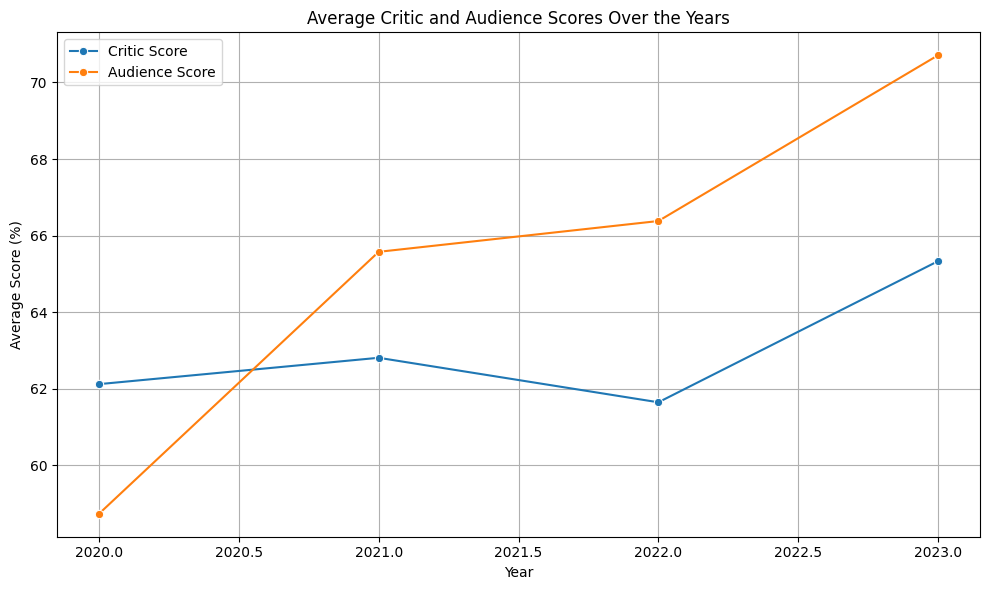

In [10]:
# ------------------------------
# Q1: Scores over time (Unit: Year)
# ------------------------------
# Convert critic_score and audience_score to numeric safely
merged_df['critic_score'] = pd.to_numeric(
    merged_df['critic_score'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)

merged_df['audience_score'] = pd.to_numeric(
    merged_df['audience_score'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)

# Changing the unit of analysis by grouping on yearly basis.
q1_df = merged_df.groupby('year')[['critic_score', 'audience_score']].mean().reset_index()
q1_df.to_csv("Scores_By_Year.csv", index=False)

# Plotting the result.
plt.figure(figsize=(10, 6))
sns.lineplot(data=q1_df, x='year', y='critic_score', marker='o', label='Critic Score')
sns.lineplot(data=q1_df, x='year', y='audience_score', marker='o', label='Audience Score')
plt.title('Average Critic and Audience Scores Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Score (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()

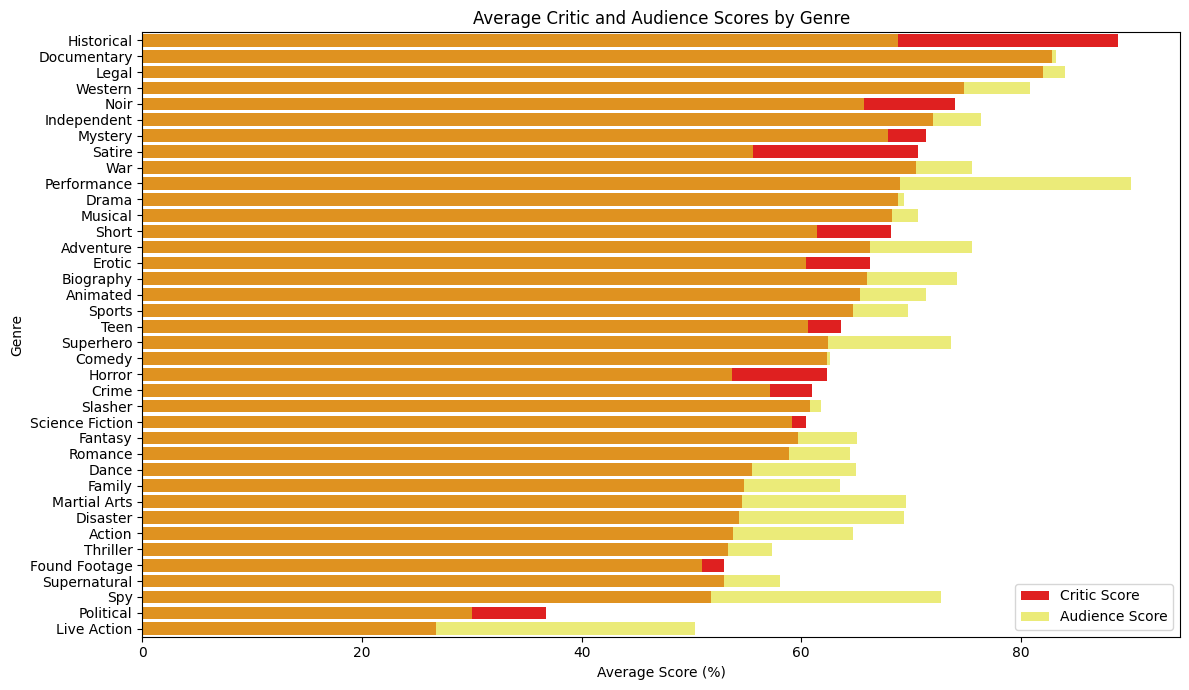

In [11]:
# ------------------------------
# Q2: Genre-based score comparison (Unit: Genre)
# ------------------------------
# Clean and explode genres
merged_df['genres'] = (
    merged_df['genres']
    .astype(str)
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.split(", ")
)
# Explode genres into individual rows
genre_exploded = merged_df.explode('genres')

# Grouping on genre and calculating mean scores
q2_df = genre_exploded.groupby('genres')[['critic_score', 'audience_score']].mean().reset_index().dropna()
q2_df.to_csv("Scores_by_Genre.csv", index=False)

# Plotting the results
plt.figure(figsize=(12, 7))
q2_sorted = q2_df.sort_values(by='critic_score', ascending=False)
sns.barplot(data=q2_sorted, x='critic_score', y='genres', color='red', label='Critic Score')
sns.barplot(data=q2_sorted, x='audience_score', y='genres', color='yellow', label='Audience Score', alpha=0.6)
plt.title('Average Critic and Audience Scores by Genre')
plt.xlabel('Average Score (%)')
plt.ylabel('Genre')
plt.legend()
plt.tight_layout()

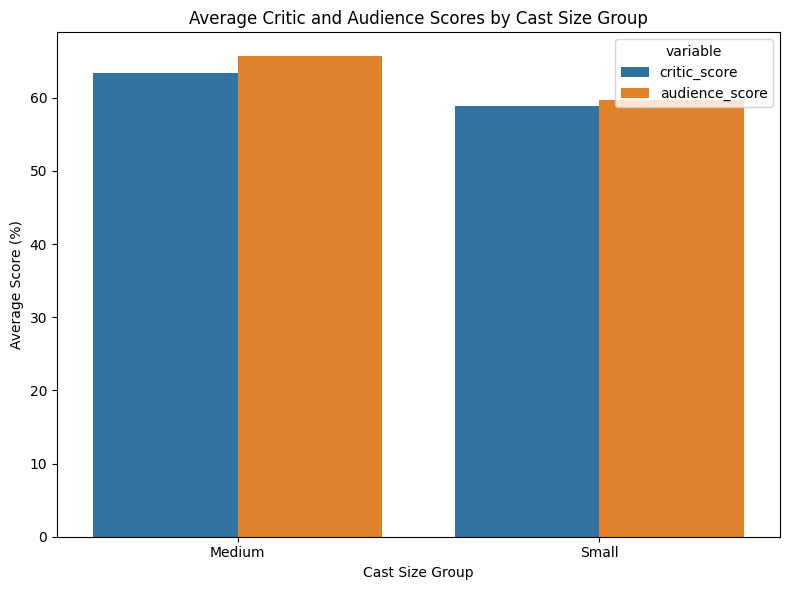

In [12]:
# ------------------------------
# Q3: Average Scores by Cast Size Group (Unit: Cast Size Group)
# ------------------------------

# Estimate number of cast members
merged_df['cast_size'] = merged_df['cast'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

# Categorize cast size into groups
def categorize_cast_size(n):
    if n <= 3:
        return 'Small'
    elif 4 <= 6:
        return 'Medium'
    else:
        return 'Large'

merged_df['cast_group'] = merged_df['cast_size'].apply(categorize_cast_size)

# Grouping by cast size group and calculating average scores
q3_df = merged_df.groupby('cast_group')[['critic_score', 'audience_score']].mean().reset_index()
q3_df.to_csv("Cast_group_vs_scores.csv", index=False)

# Plotting the result.
plt.figure(figsize=(8, 6))
sns.barplot(data=q3_df.melt(id_vars='cast_group'), x='cast_group', y='value', hue='variable')
plt.title('Average Critic and Audience Scores by Cast Size Group')
plt.xlabel('Cast Size Group')
plt.ylabel('Average Score (%)')
plt.tight_layout()